# Figure 1 — Cell-type overview

Plots:

- **b**: UMAP of all cells, coloured by cell type
- **c**: UMAP of all cells, coloured by condition (CTRL vs EXP)
- **d**: UMAP of fibroblast subset, coloured by fibroblast subtype (FIB1-8, DP1, DP2, DS)
- **e**: UMAP of fibroblast subset, coloured by condition
- **f**: Dotplot of marker genes per fibroblast subtype

Reads `adata_harmony.h5ad` (panels b, c) and `sub_fibroblasts.h5ad` (panels d, e, f) from
the preprocessing notebook's final save.

## Imports

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Output directory for the saved figure SVGs
out_dir = Path('../manuscript_figures/figure_1')
out_dir.mkdir(parents=True, exist_ok=True)

sc.settings.set_figure_params(dpi=80, facecolor='white', frameon=False)

## Load processed data

In [2]:
adata     = sc.read_h5ad('../../results/adata_harmony_caroline_belgium.h5ad')
sub_fibro = sc.read_h5ad('../../results/sub_fibroblasts.h5ad')

print(f'adata:     {adata.n_obs} cells, {adata.n_vars} genes')
print(f'sub_fibro: {sub_fibro.n_obs} cells, {sub_fibro.n_vars} genes')

adata:     36316 cells, 32285 genes
sub_fibro: 15419 cells, 32285 genes


## Display rename for fibroblast subtypes

For the figure, `Lower dermis Fibroblast 1-4` are displayed as `FIB5-8` to match the
manuscript labeling. We do this in a separate `obs` column (`celltype_display`) so the
underlying h5ad annotation stays untouched.

In [3]:
# ---- Display renames ----
# adata (broad) — show as T cells 1/2 in the figure
adata_display_rename = {
    "CD4- CD8- T cells": "T cells 1",
    "CD4+/CD8+ T cells": "T cells 2",
}
adata.obs['celltype_display'] = (
    adata.obs['celltype_caro'].astype(str).replace(adata_display_rename)
)

# sub_fibro — rename Lower dermis FIB 1-4 to FIB 5-8 for display
sub_fibro_display_rename = {
    "Lower dermis Fibroblast 1": "Fibroblast 5",
    "Lower dermis Fibroblast 2": "Fibroblast 6",
    "Lower dermis Fibroblast 3": "Fibroblast 7",
    "Lower dermis Fibroblast 4": "Fibroblast 8",
}
sub_fibro.obs['celltype_display'] = (
    sub_fibro.obs['celltype'].astype(str).replace(sub_fibro_display_rename)
)

print('adata display label counts:')
print(adata.obs['celltype_display'].value_counts())
print('\nsub_fibro display label counts:')
print(sub_fibro.obs['celltype_display'].value_counts())

adata display label counts:
celltype_display
Fibroblasts               15419
Macrophages                4651
Keratinocytes              4158
Langerhans cells           2818
T cells 2                  2452
Endothelial cells          2176
T cells 1                   959
Schwann cells               869
Lymphatic cells             834
Vascular smooth muscle      707
Monocytes                   466
Melanocytes                 464
Mast cells                  343
Name: count, dtype: int64

sub_fibro display label counts:
celltype_display
Fibroblast 3    2859
Fibroblast 2    2364
DP1             2362
Fibroblast 1    2088
DS              2005
DP2             1731
Fibroblast 5     617
Fibroblast 4     420
Fibroblast 6     387
Fibroblast 8     358
Fibroblast 7     228
Name: count, dtype: int64


## Colour palettes

Used across panels b/d for cell-type and fibroblast-subtype consistency. Conditions use
the standard CTRL/EXP scheme (blue/orange).

In [4]:
# ---- Broad cell-type palette (panel b, on adata) ----
# Keys match the *displayed* labels (T cells 1/2) since panel b colors by celltype_display.
broad_celltype_cmap = {
    "Fibroblasts":            "#D62928",
    "Macrophages":            "#B6BD61",
    "DS":                     "#8559A5",
    "Keratinocytes":          "#D19CFF",
    "Langerhans cells":       "#8C574C",
    "T cells 2":              "#FFFA4D",
    "Endothelial cells":      "#269E68",
    "T cells 1":              "#1D2451",
    "Schwann cells":          "#9DD089",
    "Lymphatic cells":        "#D87AB1",
    "Vascular smooth muscle": "#F69696",
    "Monocytes":              "#FCBA78",
    "Melanocytes":            "#AEC7E8",
    "Mast cells":             "#1DBFCF",
}

# Mirror Lower dermis hexes onto the displayed FIB5-8 labels
broad_celltype_cmap.update({
    "CD4- CD8- T cells": broad_celltype_cmap["T cells 1"],
    "CD4+/CD8+ T cells": broad_celltype_cmap["T cells 2"],
})
# ---- Fibroblast subtype palette (panels d, f, on sub_fibro) ----
# Includes the FIB5-8 display aliases mirroring the Lower dermis hexes.
fib_celltype_cmap = {
    "Fibroblast 1":              "#B6BD61",
    "Fibroblast 2":              "#AEC7E8",
    "Fibroblast 3":              "#FCBA78",
    "Fibroblast 4":              "#D62928",
    "Lower dermis Fibroblast 1": "#D87AB1",
    "Lower dermis Fibroblast 2": "#1DBFCF",
    "Lower dermis Fibroblast 3": "#F7F74D",
    "Lower dermis Fibroblast 4": "#262B66",
    "DP1":                       "#269E68",
    "DP2":                       "#8C574C",
    "DS":                        "#8559A5",
}
# Mirror Lower dermis hexes onto the displayed FIB5-8 labels
fib_celltype_cmap.update({
    "Fibroblast 5": fib_celltype_cmap["Lower dermis Fibroblast 1"],
    "Fibroblast 6": fib_celltype_cmap["Lower dermis Fibroblast 2"],
    "Fibroblast 7": fib_celltype_cmap["Lower dermis Fibroblast 3"],
    "Fibroblast 8": fib_celltype_cmap["Lower dermis Fibroblast 4"],
})


# ---- Condition palette (panels c, e) ----
condition_cmap = {
    "Control":  "#1F77B4",
    "Expanded": "#FF7F0E",
}

## Panel b — UMAP of all cells, by cell type

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


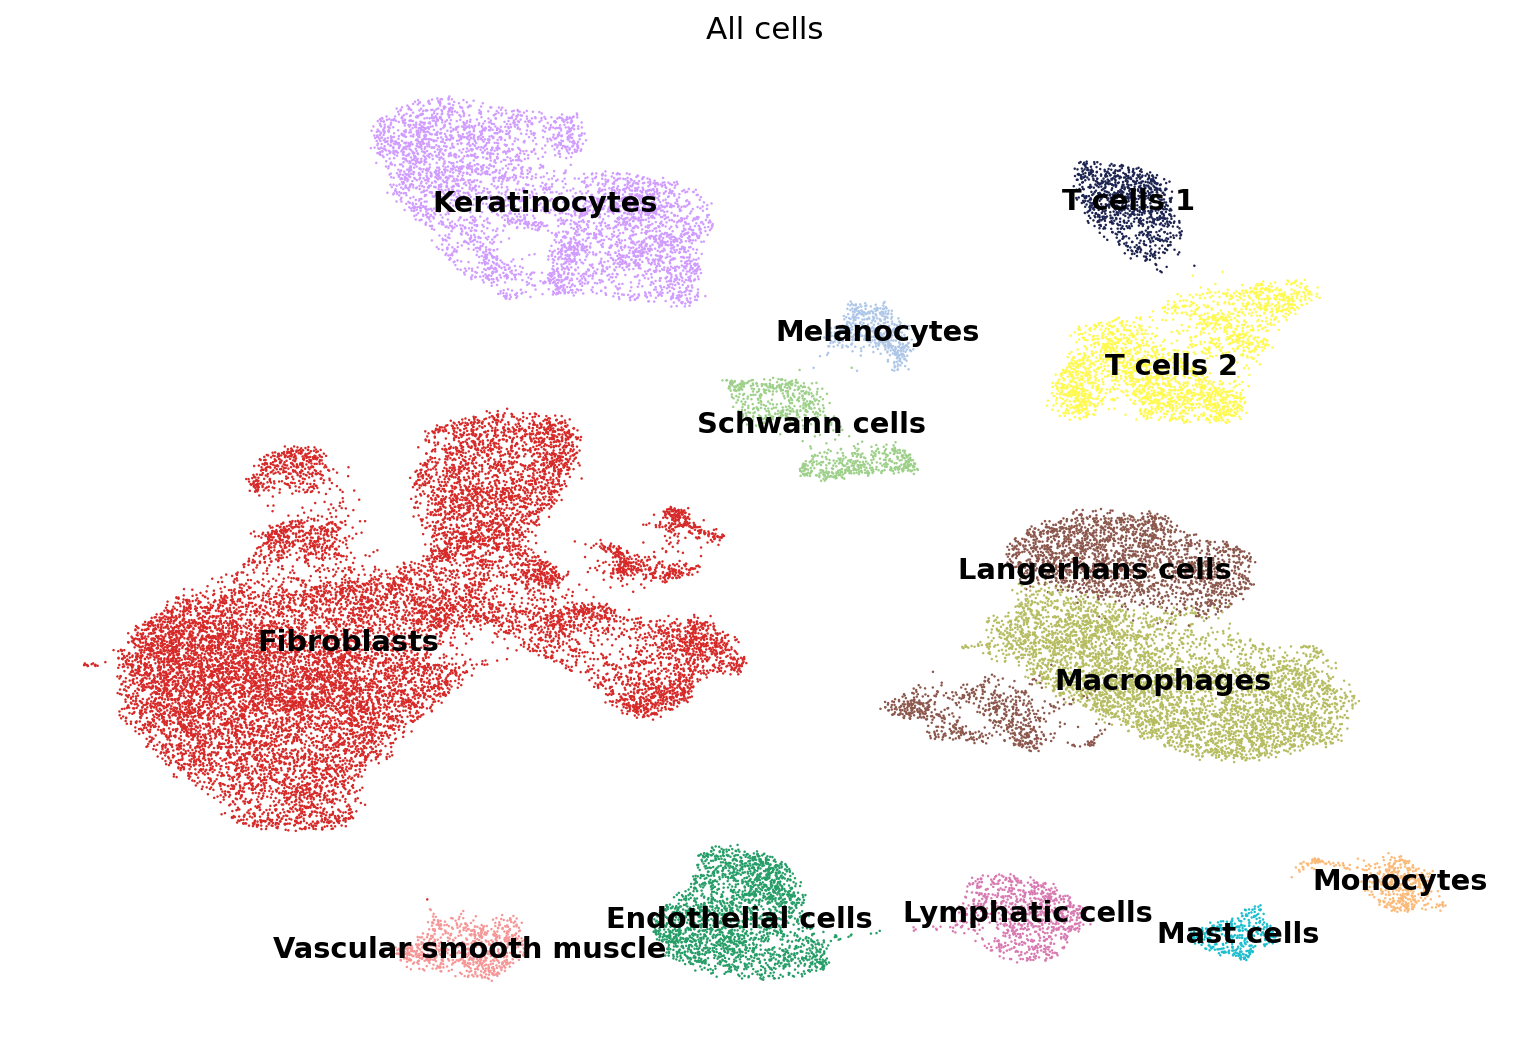

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
sc.pl.umap(
    adata,
    color='celltype_display',
    palette=broad_celltype_cmap,
    size=5,
    ax=ax,
    show=False,
    legend_loc='on data',
    legend_fontsize=13,
    title='All cells',
)

# Rasterize the scatter points (keeps SVG file size sane while preserving vector text)
for ax_ in fig.axes:
    for artist in ax_.collections:
        artist.set_rasterized(True)

fig.savefig(out_dir / 'fig1b_umap_all_celltypes.svg',
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Panel c — UMAP of all cells, by condition

Same UMAP coordinates as panel b, recoloured to show CTRL vs EXP distribution.

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


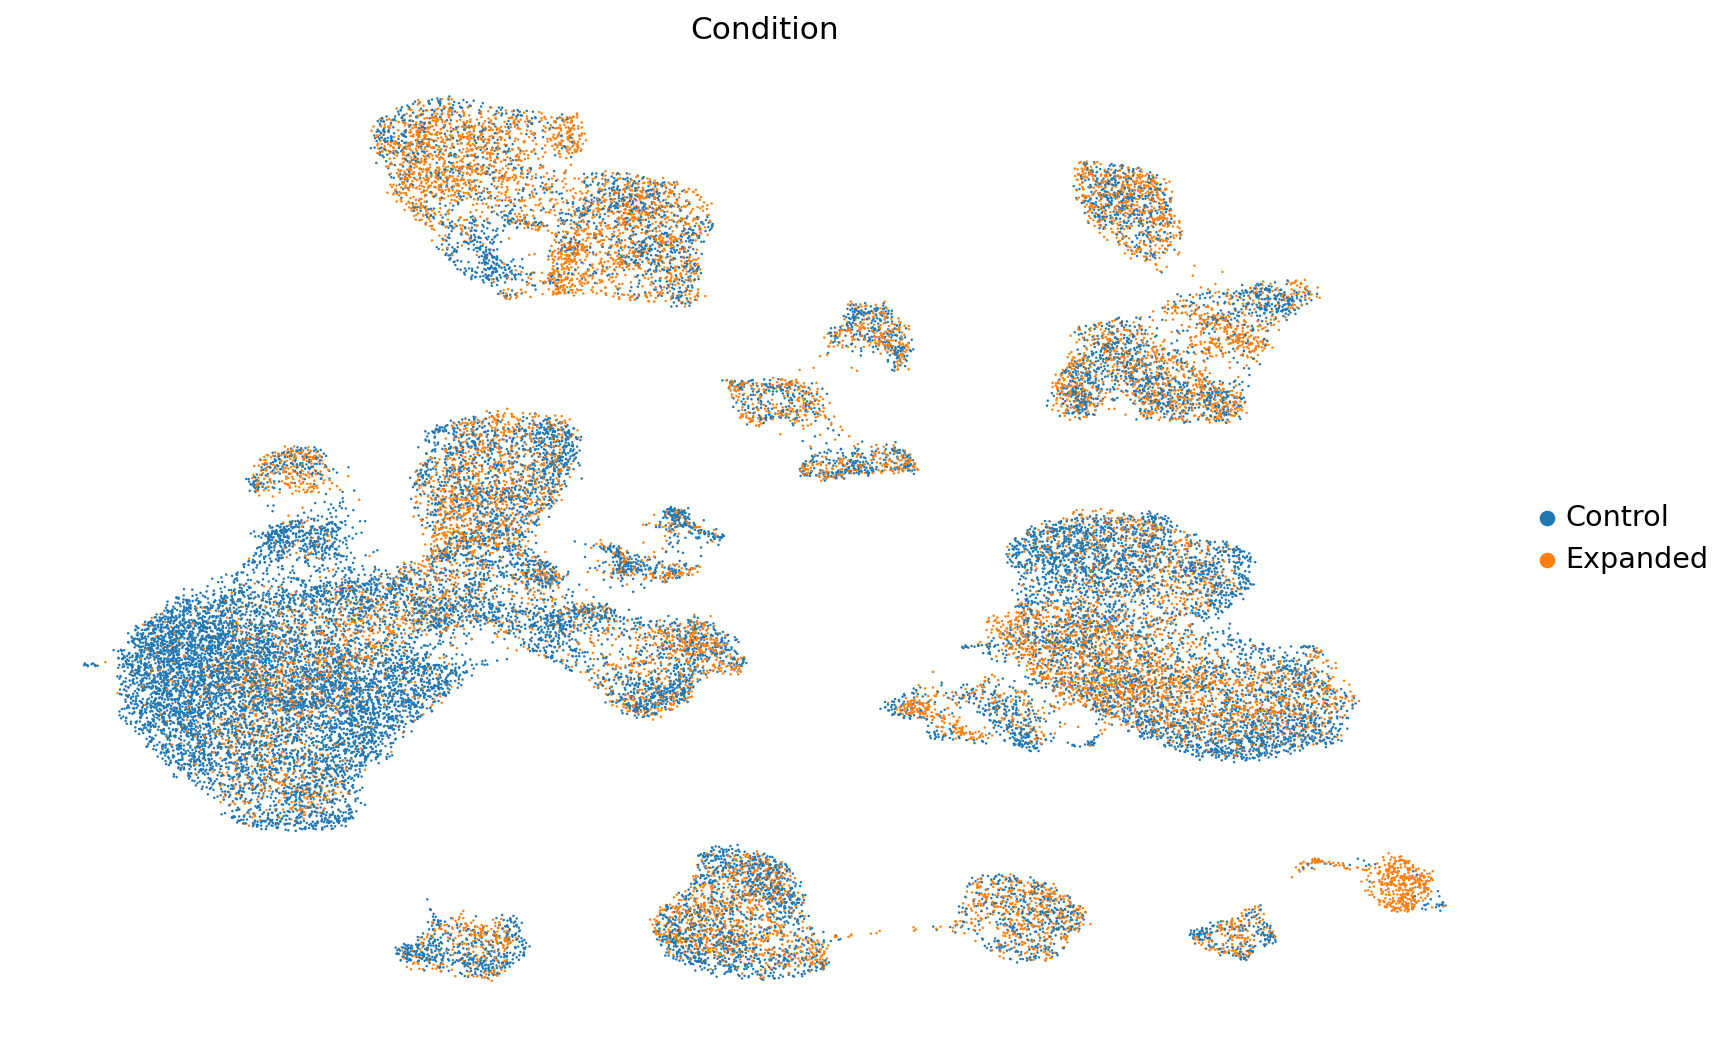

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))
sc.pl.umap(
    adata,
    color='condition',
    palette=condition_cmap,
    size=5,
    ax=ax,
    show=False,
    title='Condition',
)

for ax_ in fig.axes:
    for artist in ax_.collections:
        artist.set_rasterized(True)

fig.savefig(out_dir / 'fig1c_umap_all_condition.svg',
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Panel d — UMAP of fibroblasts, by subtype

Uses the dedicated fibroblast UMAP from `sub_fibroblasts.h5ad`.

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


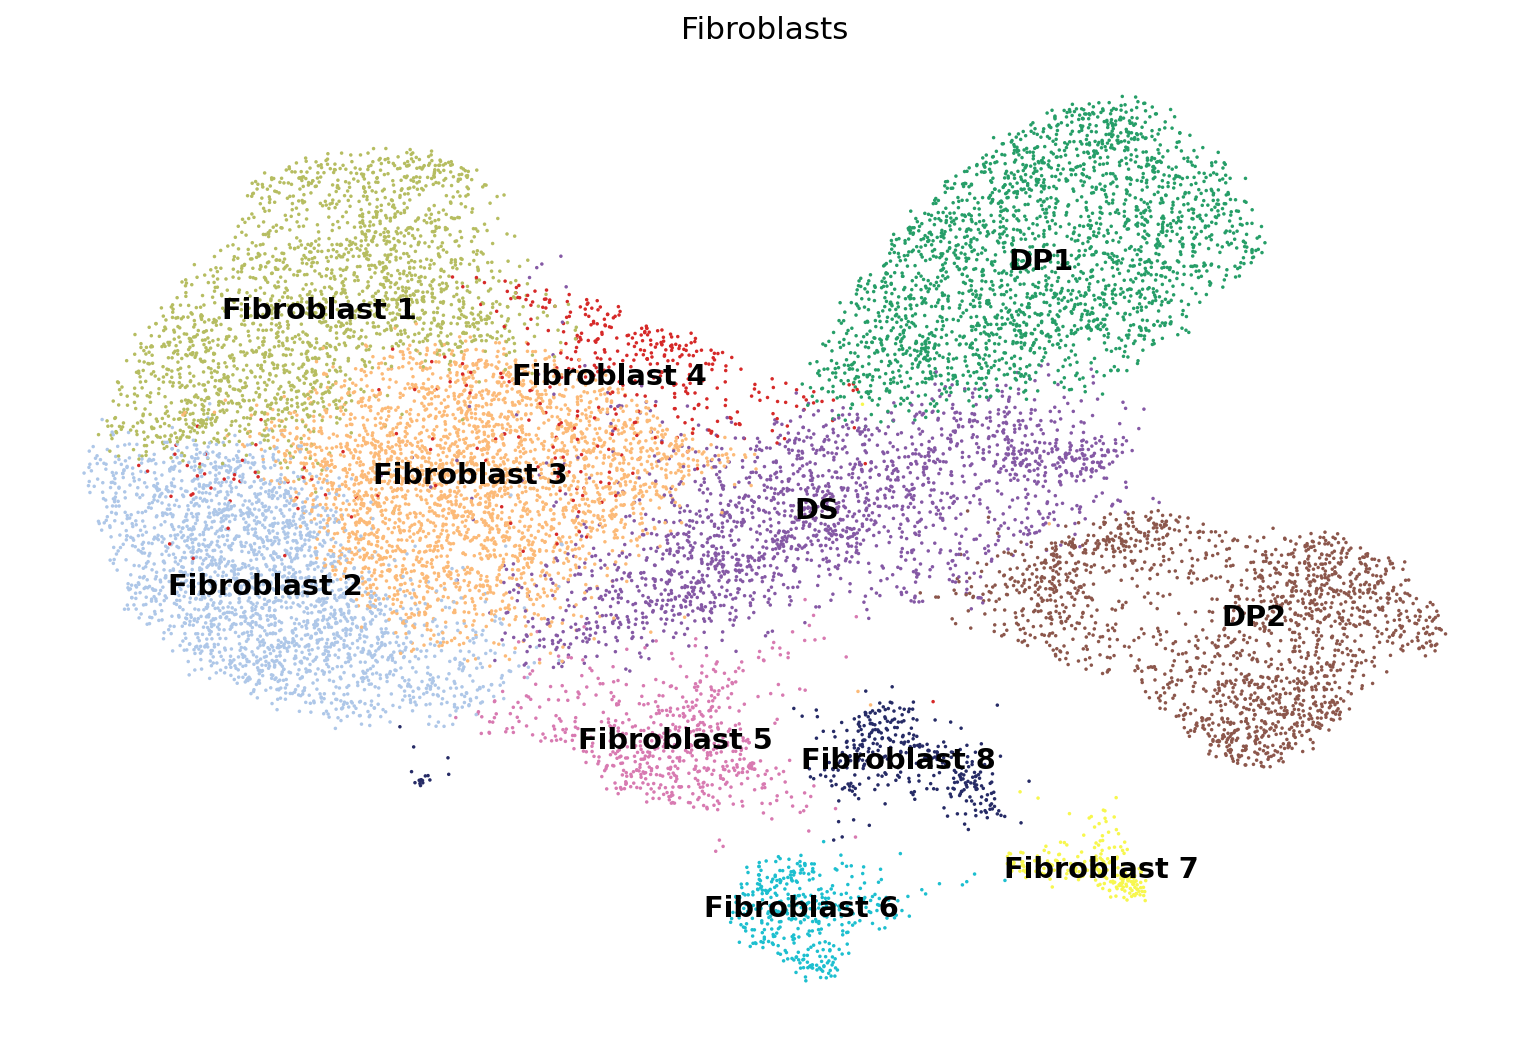

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
sc.pl.umap(
    sub_fibro,
    color='celltype_display',
    palette=fib_celltype_cmap,
    size=10,
    ax=ax,
    show=False,
    legend_loc='on data',
    legend_fontsize=13,
    title='Fibroblasts',
)

for ax_ in fig.axes:
    for artist in ax_.collections:
        artist.set_rasterized(True)

fig.savefig(out_dir / 'fig1d_umap_fibroblasts_subtypes.svg',
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Panel e — UMAP of fibroblasts, by condition

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


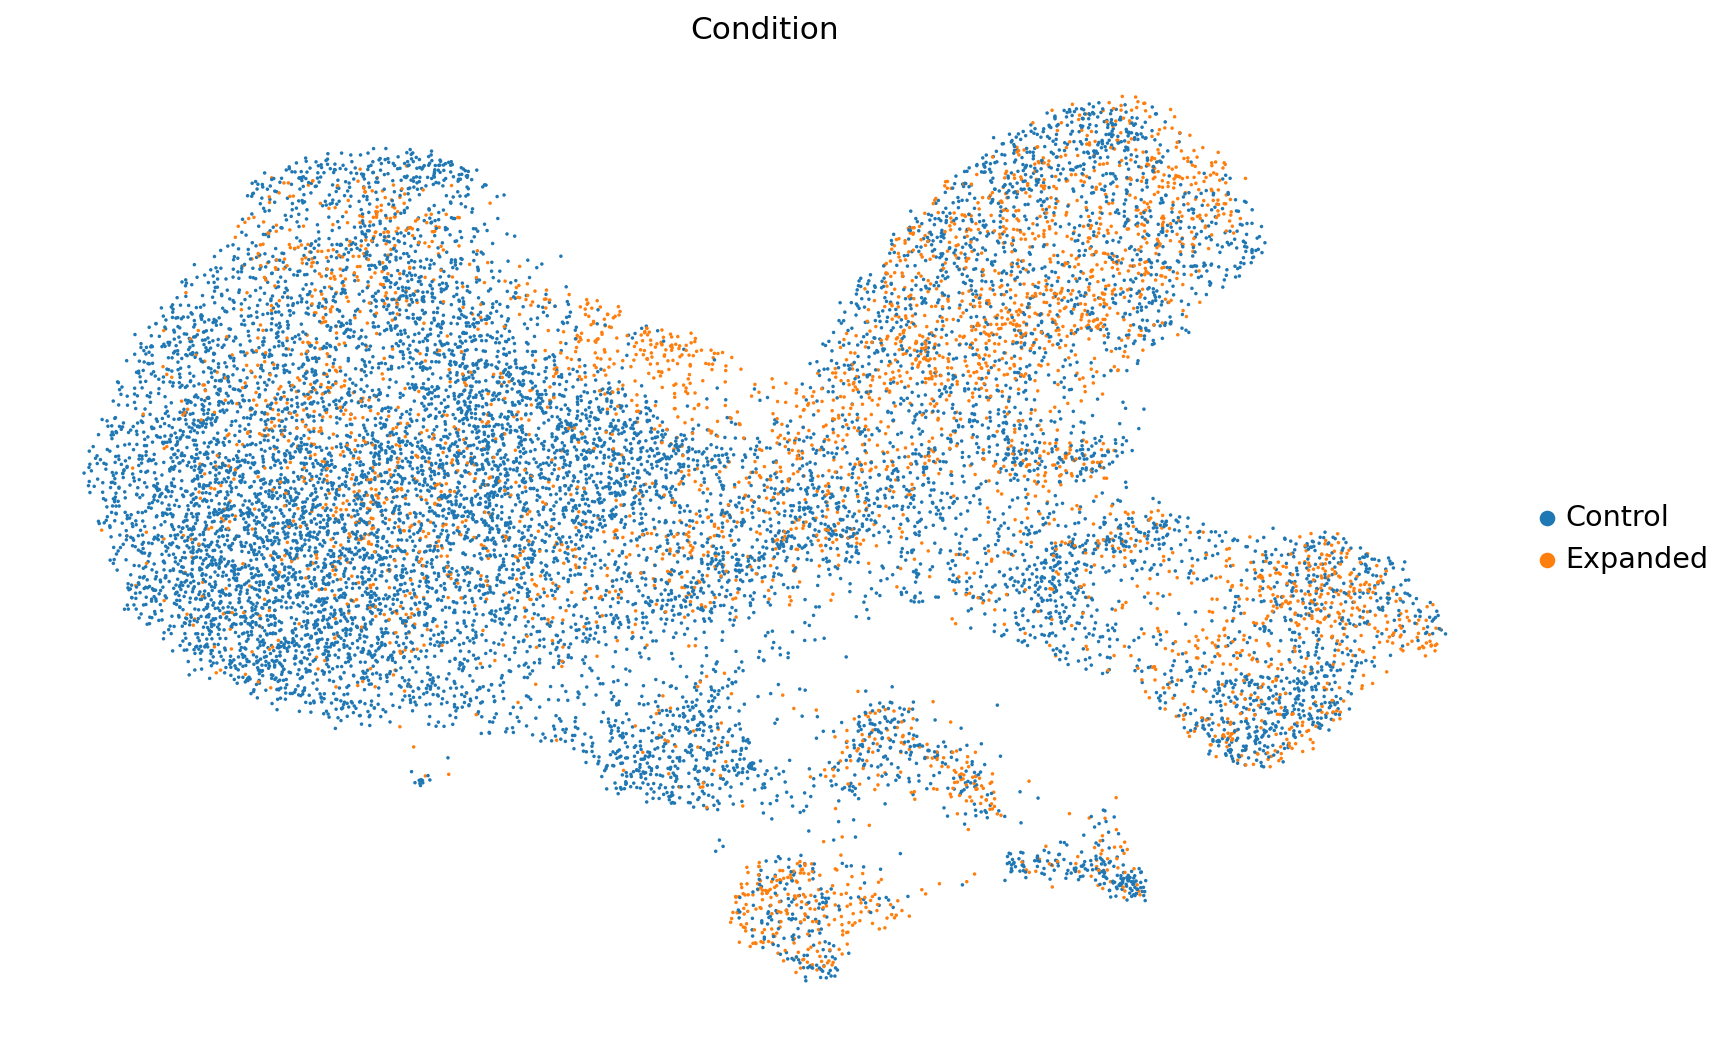

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))
sc.pl.umap(
    sub_fibro,
    color='condition',
    palette=condition_cmap,
    size=10,
    ax=ax,
    show=False,
    title='Condition',
)

for ax_ in fig.axes:
    for artist in ax_.collections:
        artist.set_rasterized(True)

fig.savefig(out_dir / 'fig1e_umap_fibroblasts_condition.svg',
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Panel f — Marker gene dotplot per fibroblast subtype

Transcribed marker gene list from the figure image (left-to-right on the x-axis).
Dot size = fraction of cells in group expressing the gene. Colour = mean expression.

In [9]:
# Marker gene list (transcribed from the figure x-axis, in order)
panel_f_genes = [
    'Qpct', 'Wnt5a', 'Sema3a', 'Sulf2', 'C4b', 'Fgl2', 'Atf3', 'Klf2',
    'Gadd45g', 'Osr2', 'Tnc', 'Pdpn', 'Timp1', 'Gpx3', 'Lpl', 'Col14a1',
    'Gpc3', 'Ccl11', 'Steap4', 'Myod1', 'Chodl', 'Pax7', 'Cox6c', 'Rpl41',
    'Serf2', 'Coch', 'Fmod', 'Crabp1', 'Lef1', 'Igfbp3', 'Prlr', 'Postn',
    'Cdh11', 'Slit2',
]

# Y-axis order: FIB1-8 (using displayed labels), then DP1, DP2, DS
fib_order = [
    'Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4',
    'Fibroblast 5', 'Fibroblast 6', 'Fibroblast 7', 'Fibroblast 8',
    'DP1', 'DP2', 'DS',
]
sub_fibro.obs['celltype_display'] = pd.Categorical(
    sub_fibro.obs['celltype_display'], categories=fib_order, ordered=True,
)

# Sanity check: warn about any genes not present
missing = [g for g in panel_f_genes if g not in sub_fibro.var_names]
if missing:
    print(f'WARNING: {len(missing)} marker gene(s) not found in sub_fibro: {missing}')
genes_present = [g for g in panel_f_genes if g in sub_fibro.var_names]

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:169: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will b

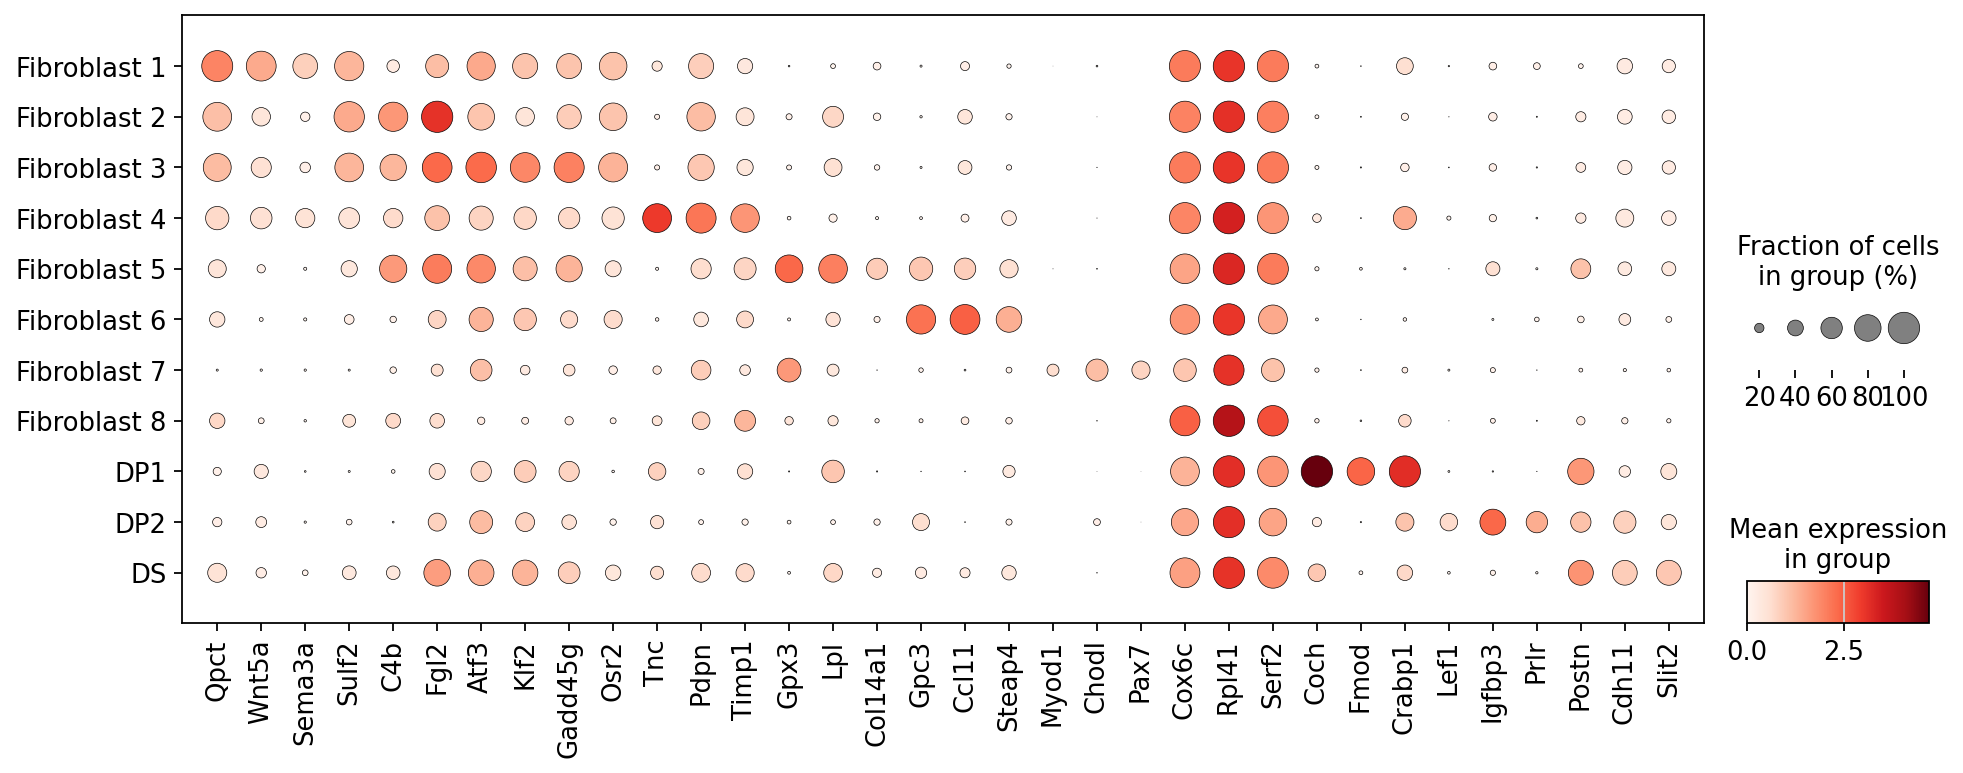

In [15]:
# Use log-normalized counts for visualization (not z-scored)
sub_fibro.X = sub_fibro.layers['logcounts']

dp = sc.pl.dotplot(
    sub_fibro,
    var_names=genes_present,
    groupby='celltype_display',
    categories_order=fib_order,
    cmap='Reds',          # use Reds
    dot_max=1.0,
    dot_min=0,
    figsize=(14, 5),
    return_fig=True,
    show=False,
)

dp = dp.style(
    cmap='Reds',          # IMPORTANT: repeat cmap here, otherwise it reverts to winter
    dot_edge_color='black',
    dot_edge_lw=0.3,
)

dp.savefig(out_dir / 'fig1f_marker_dotplot.svg', dpi=300, bbox_inches='tight')
plt.show()